In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
train = pd.read_parquet('/content/train.parquet')
test = pd.read_parquet('/content/test.parquet')

In [62]:
X = train.drop(['Bankrupt?'], axis=1)
y = train['Bankrupt?']

In [63]:
y.value_counts(normalize=True)

,proportion
Bankrupt?,
0,0.967735
1,0.032265


In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [66]:
!pip install optuna

In [67]:
from imblearn.over_sampling import SMOTE
import optuna

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [68]:
# import optuna
# from imblearn.combine import SMOTETomek

# smt = SMOTETomek(random_state=42)
# X_train_sm, y_train_sm = smt.fit_resample(X_train, y_train)

In [69]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    model = RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_sm, y_train_sm)

    # 확률 예측
    y_prob = model.predict_proba(X_test)[:, 1]

    # 🔥 threshold까지 같이 최적화
    thresholds = np.arange(0.1, 0.5, 0.05)
    best_f2 = 0

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        if f2 > best_f2:
            best_f2 = f2

    return best_f2

선택된 변수 개수: 28


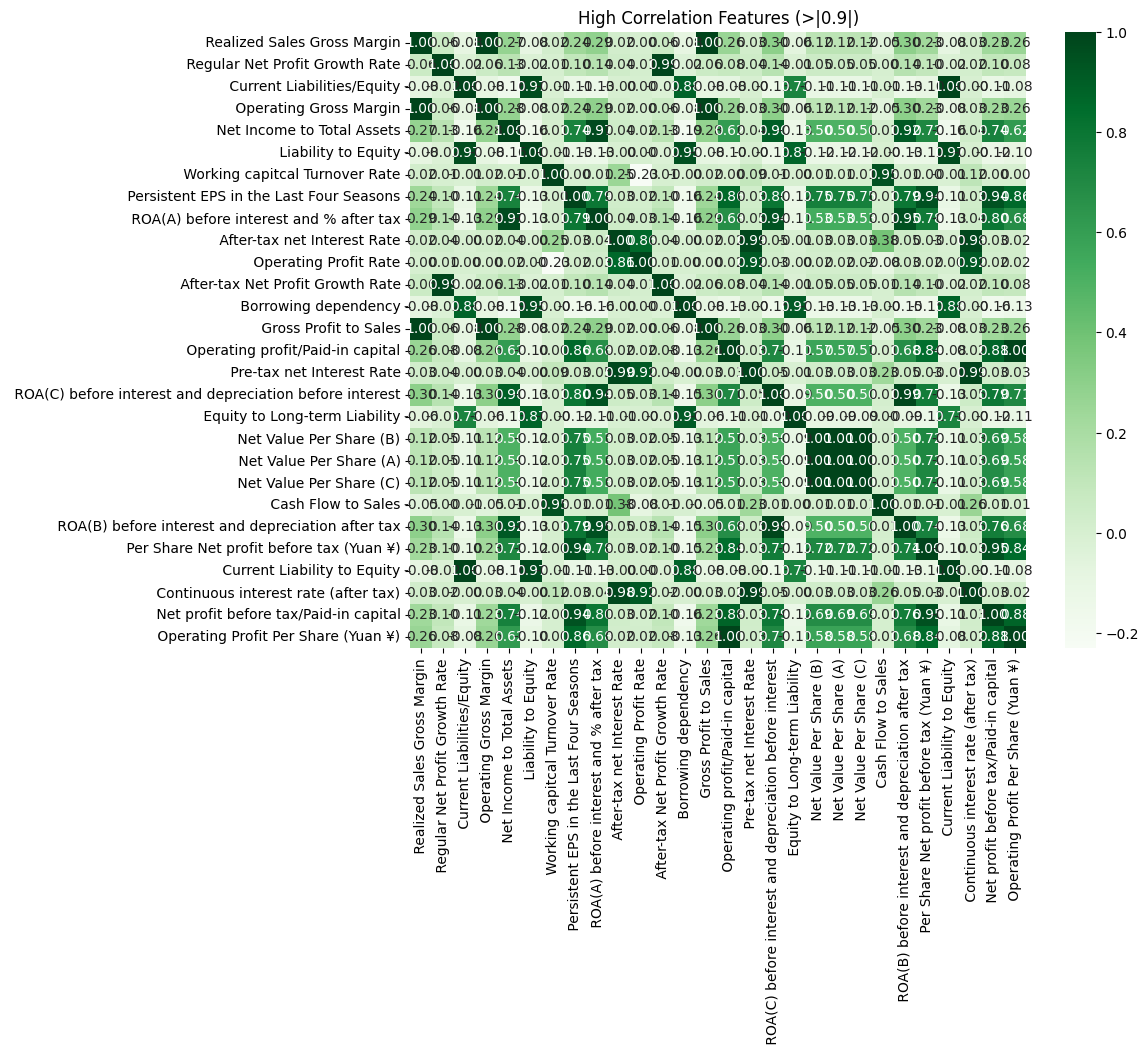

In [90]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 1. 상관계수 행렬
# ===============================
corr_matrix = train.corr(numeric_only=True)

# ===============================
# 2. 타깃 제거 (선택)
# ===============================
if 'Bankrupt?' in corr_matrix.columns:
    corr_matrix = corr_matrix.drop(index='Bankrupt?', columns='Bankrupt?')

# ===============================
# 3. 상관도 0.9 이상 변수 찾기
# ===============================
threshold = 0.9

# 상관도가 높은 위치 찾기
high_corr = np.where((corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1.0))

# 해당 변수 이름 추출
high_corr_features = set()

for i, j in zip(*high_corr):
    high_corr_features.add(corr_matrix.columns[i])
    high_corr_features.add(corr_matrix.columns[j])

high_corr_features = list(high_corr_features)

print("선택된 변수 개수:", len(high_corr_features))

# ===============================
# 4. 필터링된 상관행렬
# ===============================
filtered_corr = corr_matrix.loc[high_corr_features, high_corr_features]

# ===============================
# 5. 히트맵 시각화
# ===============================
plt.figure(figsize=(10,8))

sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap="Greens",   # 연두 계열
    square=True
)

plt.title("High Correlation Features (>|0.9|)")
plt.show()

In [70]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best F2:", study.best_value)

[I 2026-03-28 19:09:07,752] A new study created in memory with name: no-name-ab0199e6-a598-4f60-b3c7-24192ce5253c
[I 2026-03-28 19:09:30,953] Trial 0 finished with value: 0.576036866359447 and parameters: {'n_estimators': 324, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 20, 'max_features': 'log2'}. Best is trial 0 with value: 0.576036866359447.
[I 2026-03-28 19:09:48,579] Trial 1 finished with value: 0.6067961165048543 and parameters: {'n_estimators': 347, 'max_depth': 9, 'min_samples_split': 26, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 1 with value: 0.6067961165048543.
[I 2026-03-28 19:09:57,711] Trial 2 finished with value: 0.5341880341880342 and parameters: {'n_estimators': 386, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 1 with value: 0.6067961165048543.
[I 2026-03-28 19:10:13,023] Trial 3 finished with value: 0.5687203791469194 and parameters: {'n_estimators': 289, 'max_depth': 8, 'min

Best Params: {'n_estimators': 223, 'max_depth': 10, 'min_samples_split': 30, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best F2: 0.625


In [71]:
best_model = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [72]:
# best_model.fit(X_train_sm, y_train_sm)

# # ===============================
# # 8. 🔥 threshold 정밀 탐색
# # ===============================
# y_prob = best_model.predict_proba(X_test)[:, 1]

# thresholds = np.arange(0.01, 0.5, 0.01)
# best_th = 0.5
# best_f2 = 0

# for th in thresholds:
#     y_pred = (y_prob >= th).astype(int)
#     f2 = fbeta_score(y_test, y_pred, beta=2)

#     if f2 > best_f2:
#         best_f2 = f2
#         best_th = th

# print("\n✅ Best Threshold:", best_th)
# print("✅ Best F2:", best_f2)


In [73]:
thresholds = np.linspace(0.05, 0.4, 400)

best_th = 0
best_f2 = 0

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f2 = fbeta_score(y_val, y_pred, beta=2)

    # 🔥 핵심 조건 (조정 가능)
    if precision >= 0.35 and recall >= 0.7:
        if f2 > best_f2:
            best_f2 = f2
            best_th = th

In [74]:
best_model.fit(X_train_sm, y_train_sm)
import numpy as np
from sklearn.metrics import fbeta_score, precision_score, recall_score

y_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.4, 300)

best_th = 0
best_f2 = 0

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)

    f2 = fbeta_score(y_val, y_pred, beta=2)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    # 🔥 조건 추가 (핵심!)
    if precision >= 0.30:   # 최소 precision 제한
        if f2 > best_f2:
            best_f2 = f2
            best_th = th

print("✅ Best Threshold:", best_th)
print("✅ Best F2:", best_f2)

✅ Best Threshold: 0.3988294314381271
✅ Best F2: 0.8108108108108109


In [78]:
# ===============================
# 1. validation 기준 최종 예측
# ===============================
y_pred_val = (y_prob >= best_th).astype(int)

# ===============================
# 2. 성능 출력
# ===============================
from sklearn.metrics import classification_report, confusion_matrix

print("\n📊 [Validation Classification Report]")
print(classification_report(y_val, y_pred_val))

# ===============================
# 3. Confusion Matrix 출력
# ===============================
cm = confusion_matrix(y_val, y_pred_val)

print("\n📌 Confusion Matrix")
print(cm)


📊 [Validation Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       739
           1       0.46      1.00      0.63        24

    accuracy                           0.96       763
   macro avg       0.73      0.98      0.81       763
weighted avg       0.98      0.96      0.97       763


📌 Confusion Matrix
[[711  28]
 [  0  24]]


In [80]:
# ===============================
# 1. test 데이터 불러오기
# ===============================
import pandas as pd

test_df = pd.read_parquet('/content/test.parquet')

# ===============================
# 2. ID 분리
# ===============================
test_id = test_df['ID']

# ===============================
# 3. feature 맞추기 (중요🔥)
# ===============================
X_test_submit = test_df[X.columns]

# ===============================
# 4. 확률 예측
# ===============================
y_prob_submit = best_model.predict_proba(X_test_submit)[:, 1]

# ===============================
# 5. 🔥 최적 threshold 적용
# ===============================
y_pred_submit = (y_prob_submit >= best_th).astype(int)

# ===============================
# 6. 제출 파일 생성
# ===============================
submission = pd.DataFrame({
    'ID': test_id,
    'Bankrupt?': y_pred_submit
})

submission.to_csv('result.csv', index=False)

print("✅ submission.csv 생성 완료")

✅ submission.csv 생성 완료


In [81]:
# 중요도 추출
importances = best_model.feature_importances_

# 데이터프레임 생성
feat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# 중요도 높은 순 정렬
feat_importance = feat_importance.sort_values(by='importance', ascending=False)

print(feat_importance.head(20))  # 상위 20개

                                              feature  importance
8                         After-tax net Interest Rate    0.054241
10               Continuous interest rate (after tax)    0.053223
90                 Net Income to Stockholder's Equity    0.046874
68                  Retained Earnings to Total Assets    0.042973
19            Persistent EPS in the Last Four Seasons    0.038126
23           Per Share Net profit before tax (Yuan ¥)    0.036289
36                         Total debt/Total net worth    0.033668
1    ROA(C) before interest and depreciation befor...    0.033138
43              Net profit before tax/Paid-in capital    0.032135
40                               Borrowing dependency    0.031616
37                                       Debt ratio %    0.030896
86                         Net Income to Total Assets    0.027392
9         Non-industry income and expenditure/revenue    0.026074
3    ROA(B) before interest and depreciation after...    0.023055
2         

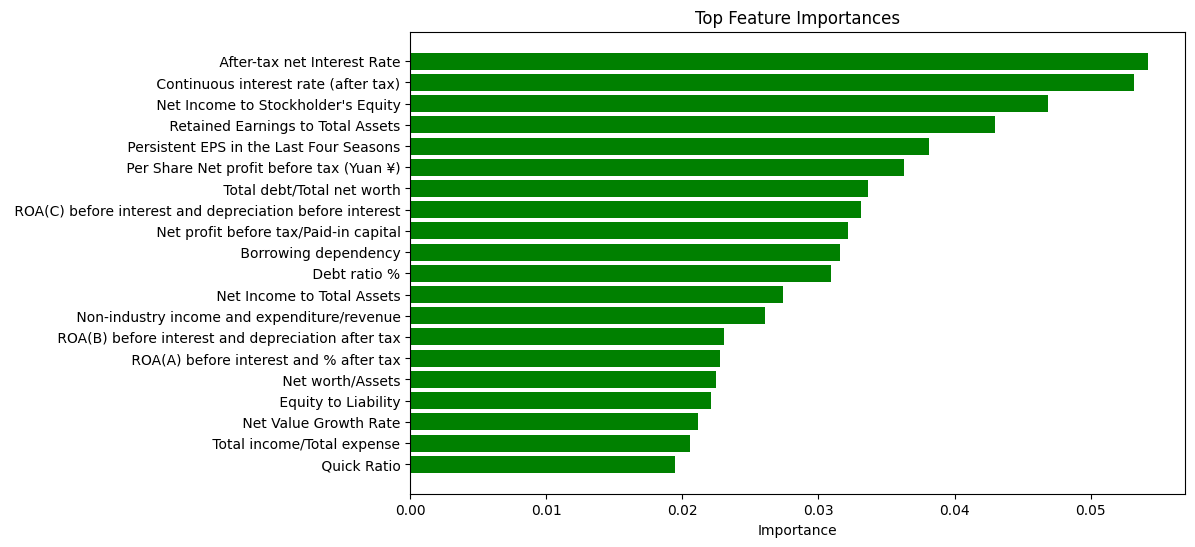

In [83]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10,6))
plt.barh(
    feat_importance['feature'][:top_n][::-1],
    feat_importance['importance'][:top_n][::-1],
    color = 'g'
)

plt.xlabel('Importance')
plt.title('Top Feature Importances')
plt.show()

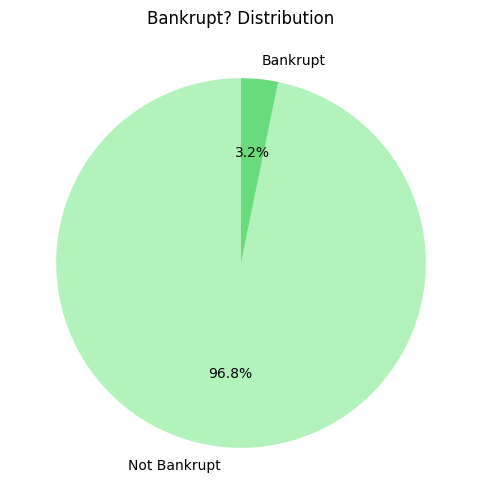

In [84]:
# 클래스 비율 계산
counts = y.value_counts()

# 라벨 설정 (0: 정상, 1: 파산)
labels = ['Not Bankrupt', 'Bankrupt']

# 색상 (연두색 계열)
colors = ['#b2f2bb', '#69db7c']  # 연한 연두, 진한 연두

# 파이차트
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Bankrupt? Distribution')
plt.show()

In [86]:
print(train.dtypes.value_counts())

float64    93
int64       4
Name: count, dtype: int64


In [89]:
import numpy as np
import pandas as pd

corr_matrix = train.corr(numeric_only=True)

# 상관행렬을 long 형태로 변환
corr_pairs = corr_matrix.abs().unstack()

# 자기 자신 제거
corr_pairs = corr_pairs[corr_pairs < 1.0]

# 정렬
corr_pairs = corr_pairs.sort_values(ascending=False)

print(corr_pairs.head(20))

Operating Gross Margin                                   Gross Profit to Sales                                      1.000000
Gross Profit to Sales                                    Operating Gross Margin                                     1.000000
Net Value Per Share (C)                                  Net Value Per Share (A)                                    0.999859
Net Value Per Share (A)                                  Net Value Per Share (C)                                    0.999859
                                                         Net Value Per Share (B)                                    0.999663
Net Value Per Share (B)                                  Net Value Per Share (A)                                    0.999663
Realized Sales Gross Margin                              Operating Gross Margin                                     0.999553
Operating Gross Margin                                   Realized Sales Gross Margin                                0.999553


In [75]:
# y_prob_test = best_model.predict_proba(X_test)[:, 1]
# y_pred_test = (y_prob_test >= best_th).astype(int)

# from sklearn.metrics import fbeta_score, classification_report

# print("\n🎯 Test F2:", fbeta_score(y_test, y_pred_test, beta=2))
# print(classification_report(y_test, y_pred_test))

In [76]:
y_pred_final = (y_prob >= best_th).astype(int)

print("\n[Classification Report]")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_final))


[Classification Report]


ValueError: Found input variables with inconsistent numbers of samples: [955, 763]

In [77]:
y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_prob >= best_th).astype(int)

train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
test_f2 = fbeta_score(y_test, y_pred_final, beta=2)

print("\nTrain F2:", train_f2)
print("Test F2:", test_f2)

if train_f2 - test_f2 > 0.1:
    print("⚠️ 과적합 의심")
else:
    print("✅ 과적합 크지 않음")

ValueError: Found input variables with inconsistent numbers of samples: [955, 763]

In [ ]:
# # ===============================
# # 1. 모델 생성
# # ===============================
# from sklearn.ensemble import RandomForestClassifier

# best_model = RandomForestClassifier(
#     **study.best_params,
#     class_weight='balanced',
#     random_state=42,
#     n_jobs=-1
# )

# # ===============================
# # 2. 모델 학습 (필수🔥)
# # ===============================
# best_model.fit(X_train_sm, y_train_sm)

# # ===============================
# # 3. validation 확률 예측
# # ===============================
# from sklearn.metrics import fbeta_score, precision_score, recall_score
# import numpy as np

# y_prob_val = best_model.predict_proba(X_val)[:, 1]

# # ===============================
# # 4. 🔥 threshold 최적화
# # ===============================
# thresholds = np.linspace(0.05, 0.4, 400)

# best_th = 0
# best_f2 = 0

# for th in thresholds:
#     y_pred_val = (y_prob_val >= th).astype(int)

#     precision = precision_score(y_val, y_pred_val)
#     recall = recall_score(y_val, y_pred_val)
#     f2 = fbeta_score(y_val, y_pred_val, beta=2)

#     # 🔥 precision + recall 조건
#     if precision >= 0.35 and recall >= 0.7:
#         if f2 > best_f2:
#             best_f2 = f2
#             best_th = th

# print("✅ Best Threshold:", best_th)
# print("✅ Best Validation F2:", best_f2)

# # ===============================
# # 5. Test 평가
# # ===============================
# y_prob_test = best_model.predict_proba(X_test)[:, 1]
# y_pred_test = (y_prob_test >= best_th).astype(int)

# print("\n🎯 Test F2:", fbeta_score(y_test, y_pred_test, beta=2))
# print(classification_report(y_test, y_pred_test))

# # ===============================
# # 6. 과적합 확인
# # ===============================
# y_prob_train = best_model.predict_proba(X_train)[:, 1]
# y_pred_train = (y_prob_train >= best_th).astype(int)

# train_f2 = fbeta_score(y_train, y_pred_train, beta=2)
# test_f2 = fbeta_score(y_test, y_pred_test, beta=2)

# print("\nTrain F2:", train_f2)
# print("Test F2:", test_f2)

# if train_f2 - test_f2 > 0.1:
#     print("⚠️ 과적합 의심")
# else:
#     print("✅ 과적합 크지 않음")

In [ ]:
# rf_model = RandomForestClassifier(
#     n_estimators=300,           # 트리 개수
#     max_depth=6,                # 과적합 방지
#     min_samples_split=20,
#     min_samples_leaf=10,
#     max_features='sqrt',        # feature 랜덤성
#     class_weight='balanced',    # 🔥 불균형 대응
#     random_state=42,
#     n_jobs=-1
# )

In [ ]:
# rf_model.fit(X_train, y_train)

In [ ]:
# y_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# thresholds = np.arange(0.01, 0.5, 0.01)

# best_th = 0.5
# best_f2 = 0

# for th in thresholds:
#     y_pred = (y_prob >= th).astype(int)
#     f2 = fbeta_score(y_test, y_pred, beta=2)

#     if f2 > best_f2:
#         best_f2 = f2
#         best_th = th

# print("✅ Best Threshold:", best_th)
# print("✅ Best F2:", best_f2)

In [ ]:
# y_pred_final = (y_prob >= best_th).astype(int)

# print("\n[Classification Report]")
# print(classification_report(y_test, y_pred_final))

# print("\nConfusion Matrix")
# print(confusion_matrix(y_test, y_pred_final))


In [ ]:
# y_train_prob = rf_model.predict_proba(X_train)[:, 1]
# y_train_pred = (y_train_prob >= best_th).astype(int)

# train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
# test_f2 = fbeta_score(y_test, y_pred_final, beta=2)

# print("\nTrain F2:", train_f2)
# print("Test F2:", test_f2)

# if train_f2 - test_f2 > 0.1:
#     print("⚠️ 과적합 의심")
# else:
#     print("✅ 과적합 크지 않음")

In [ ]:
# ===============================
# 2. ID 컬럼 분리
# ===============================
test_id = test['ID']

# 3. feature 맞추기 (중요🔥)
# ===============================
# train에서 사용한 컬럼 그대로 사용
X_test_submit = test[X.columns]

# ===============================
# 4. 확률 예측
# ===============================
y_prob_submit = best_model.predict_proba(X_test_submit)[:, 1]

# ===============================
# 5. 🔥 최적 threshold 적용
# ===============================
y_pred_submit = (y_prob_submit >= best_th).astype(int)

# ===============================
# 6. 제출 파일 생성
# ===============================
submission = pd.DataFrame({
    'ID': test_id,
    'Bankrupt?': y_pred_submit
})

submission.to_csv('result.csv', index=False)

print("✅ result.csv 생성 완료")